# Can we predict late deliveries? A preregistered study

**Spaceship ML research notebook** · 400 mock orders · January to December 2025 · author: the Spaceship team

---

**Question.** At the moment an order is placed, do its attributes (carrier, region, warehouse,
category, quantity, price, promo, month) carry enough signal to predict whether it will arrive
late?

**Why it matters.** If yes, the AI analyst gets a `predict_delay_risk` tool and operations can
act before shipments slip. If no, shipping a confident-looking probability would be worse than
shipping nothing.

**Result, up front.** The study fails both preregistered criteria: logistic regression reaches a
cross-validated **ROC AUC of 0.465** (chance is 0.5) and the permutation test yields
**p = 0.68**. The carrier differences visible in exploration are small sample noise. The
decision, recorded in `model/DECISION.md`, is **do not ship** a per order risk tool. Section 7
shows *why* the apparent structure dissolves under validation.

**How to read this.** Section 1 fixes the rules before any model is fit. Sections 2 and 3 audit
and describe the data. Section 4 explores where lateness concentrates. Sections 5 and 6 test the
models honestly. Sections 7 to 9 explain, decide and qualify.

## 1. Protocol, fixed before results

**Ship bar (preregistered).** A risk model ships only if **both** hold:

1. mean 5 fold cross validated **ROC AUC ≥ 0.65** for the reference model (logistic regression), and
2. a **permutation test p value < 0.05**: the real AUC must beat the distribution of AUCs
   obtained after shuffling the labels 100 times.

**Population.** Completed orders only: `delivered`, `delayed`, `exception`. Orders
`in_transit` (outcome unknown) and `canceled` (void) are excluded from training and from any
future scoring claim.

**Target.** `late = 1` when status is `delayed` or `exception`, else 0.

**Leakage rules.** Every feature must be knowable at order time: carrier, region, warehouse,
product category, order month, quantity, unit price, promo flag. `delivery_date`, and anything
derived from it, is excluded by construction.

**Validation design.** Stratified 5 fold cross validation (shuffled, seed 42). All encoders and
scalers live inside the pipeline, so they are fit on training folds only. Baselines come first:
a model only matters if it beats the trivial answer.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

RNG = np.random.RandomState(42)  # reserved for the permutation test (do not consume earlier)

# ---- Spaceship chart style ------------------------------------------------
CYAN, INDIGO, GREEN, AMBER, RED, SLATE = (
    "#0891b2", "#6366f1", "#059669", "#d97706", "#e11d48", "#64748b",
)
INK, INK3, GRID = "#0e1c2e", "#7d8ca0", "#dbe3ee"

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "axes.titlesize": 11.5,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 9.5,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.6,
    "xtick.color": INK3,
    "ytick.color": INK3,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "font.size": 10,
})

def style_ax(ax, ygrid_only=True):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if ygrid_only:
        ax.grid(axis="x", visible=False)
    return ax

# ---- data -------------------------------------------------------------------
df = pd.read_csv(Path("../web/data/mock_logistics_data.csv"), parse_dates=["order_date", "delivery_date"])
df["order_month"] = df["order_date"].dt.month
df["delivery_days"] = (df["delivery_date"] - df["order_date"]).dt.days

print(f"{len(df)} orders x {df.shape[1]} columns | {df.order_date.min().date()} to {df.order_date.max().date()}")
df.head(3)

400 orders x 19 columns | 2025-01-01 to 2025-12-30


,client_id,order_id,order_date,delivery_date,carrier,origin_city,destination_city,status,sku,product_category,quantity,unit_price_usd,order_value_usd,is_promo,promo_discount_pct,region,warehouse,order_month,delivery_days
0,CL-1023,ORD-2026-267300-0001,2025-10-19,2025-10-22,DHL,"London, UK","Leeds, UK",delivered,PAPER-0197,PAPER,2,13.11,26.22,0,0,UK,LON-FC1,10,3.0
1,CL-1001,ORD-2026-187805-0002,2025-01-22,2025-01-26,LaserShip,"Chicago, IL","Milwaukee, WI",delivered,CRAYON-0008,CRAYON,3,11.69,35.07,0,0,US-C,CHI-DC1,1,4.0
2,CL-1014,ORD-2026-189805-0003,2025-07-14,2025-07-18,FedEx,"Dallas, TX","San Antonio, TX",delivered,BOOK-0115,BOOK,2,21.28,42.56,0,0,US-C,DFW-DC1,7,4.0


## 2. Data audit

Before any analysis: does the file mean what it claims to mean? Each check below would have
poisoned the study silently if it failed.

In [2]:
checks = []

checks.append(("400 rows as documented", len(df) == 400))
checks.append((
    "delivery_date missing exactly for in_transit / canceled",
    bool((df["delivery_date"].isna() == df["status"].isin(["in_transit", "canceled"])).all()),
))
checks.append((
    "order_value = quantity x unit_price on every row",
    bool(np.allclose(df["order_value_usd"], df["quantity"] * df["unit_price_usd"], atol=0.011)),
))
checks.append((
    "no negative or zero delivery times",
    bool((df["delivery_days"].dropna() > 0).all()),
))
sku_per_order = df.sku.nunique() / len(df)
checks.append((f"{df.sku.nunique()} distinct SKUs in 400 orders (~{sku_per_order:.0%} unique)", True))

for label, ok in checks:
    print(("PASS  " if ok else "FAIL  ") + label)
assert all(ok for _, ok in checks)

print()
print("Status counts:")
print(df["status"].value_counts().to_string())
print()
print("Consequence: per SKU history is ~1 order, so any per SKU model is statistical theater.")

PASS  400 rows as documented
PASS  delivery_date missing exactly for in_transit / canceled
PASS  order_value = quantity x unit_price on every row
PASS  no negative or zero delivery times
PASS  355 distinct SKUs in 400 orders (~89% unique)

Status counts:
status
delivered     304
delayed        55
in_transit     27
exception      11
canceled        3

Consequence: per SKU history is ~1 order, so any per SKU model is statistical theater.


## 3. The operation at a glance

Monthly volume is noisy with no clean trend, the status mix is dominated by `delivered`, and
late orders take visibly longer than on time ones, which is the *outcome*, not a usable
predictor.

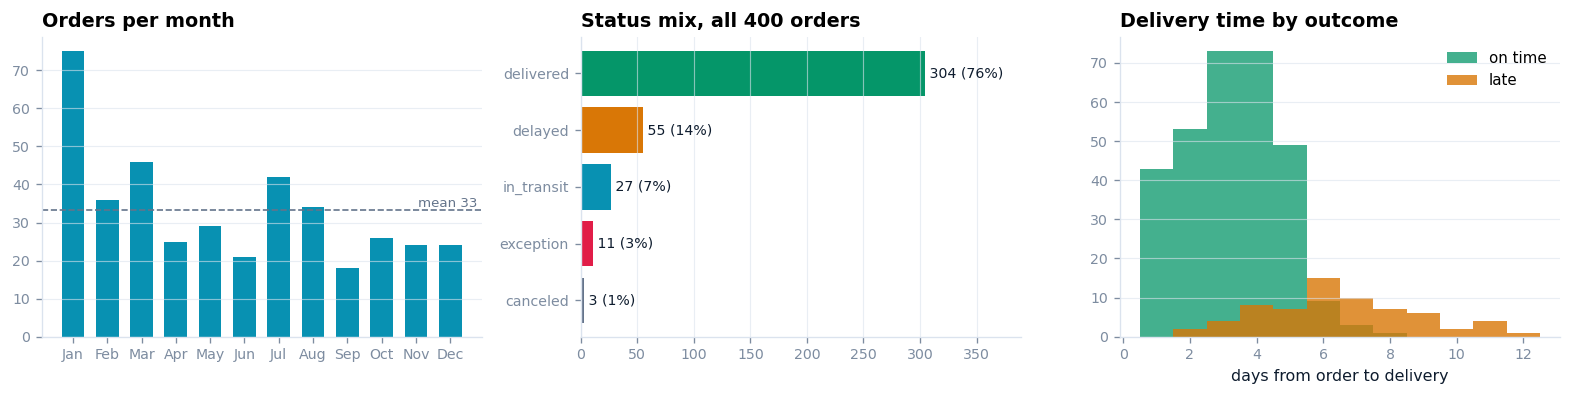

Completed orders: 370 | late: 66 (17.8%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.4))

# volume per month
monthly = df.groupby(df.order_date.dt.to_period("M")).size()
ax = style_ax(axes[0])
ax.bar([str(p.strftime("%b")) for p in monthly.index], monthly.values, color=CYAN, width=0.66)
ax.axhline(monthly.mean(), color=SLATE, lw=1, ls="--")
ax.annotate(f"mean {monthly.mean():.0f}", xy=(0.99, monthly.mean()), xycoords=("axes fraction", "data"),
            ha="right", va="bottom", fontsize=8, color=SLATE)
ax.set_title("Orders per month")

# status mix
order = ["delivered", "delayed", "in_transit", "exception", "canceled"]
colors = {"delivered": GREEN, "delayed": AMBER, "in_transit": CYAN, "exception": RED, "canceled": SLATE}
counts = df["status"].value_counts().reindex(order)
ax = style_ax(axes[1], ygrid_only=False)
ax.grid(axis="y", visible=False)
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=[colors[s] for s in counts.index[::-1]])
for b, v in zip(bars, counts.values[::-1]):
    ax.annotate(f" {v} ({v/len(df):.0%})", (b.get_width(), b.get_y() + b.get_height() / 2),
                va="center", fontsize=8.5, color=INK)
ax.set_xlim(0, counts.max() * 1.28)
ax.set_title("Status mix, all 400 orders")

# delivery time by outcome
completed = df[df.status.isin(["delivered", "delayed", "exception"])].copy()
completed["late"] = completed.status.isin(["delayed", "exception"]).astype(int)
ax = style_ax(axes[2])
bins = np.arange(0.5, completed.delivery_days.max() + 1.5)
ax.hist(completed.loc[completed.late == 0, "delivery_days"], bins=bins, color=GREEN, alpha=0.75, label="on time")
ax.hist(completed.loc[completed.late == 1, "delivery_days"], bins=bins, color=AMBER, alpha=0.8, label="late")
ax.legend()
ax.set_xlabel("days from order to delivery")
ax.set_title("Delivery time by outcome")

plt.tight_layout()
plt.show()

print(f"Completed orders: {len(completed)} | late: {completed.late.sum()} ({completed.late.mean():.1%})")

## 4. Where lateness concentrates, with honest error bars

Late rate by carrier, region and category, using the dashboard's denominator (completed
orders). Each bar carries a **Wilson 95% interval**: with samples this small the intervals are
enormous, which is the first warning that the differences may not survive validation. GLS, the
worst looking carrier, ships 8 completed orders.

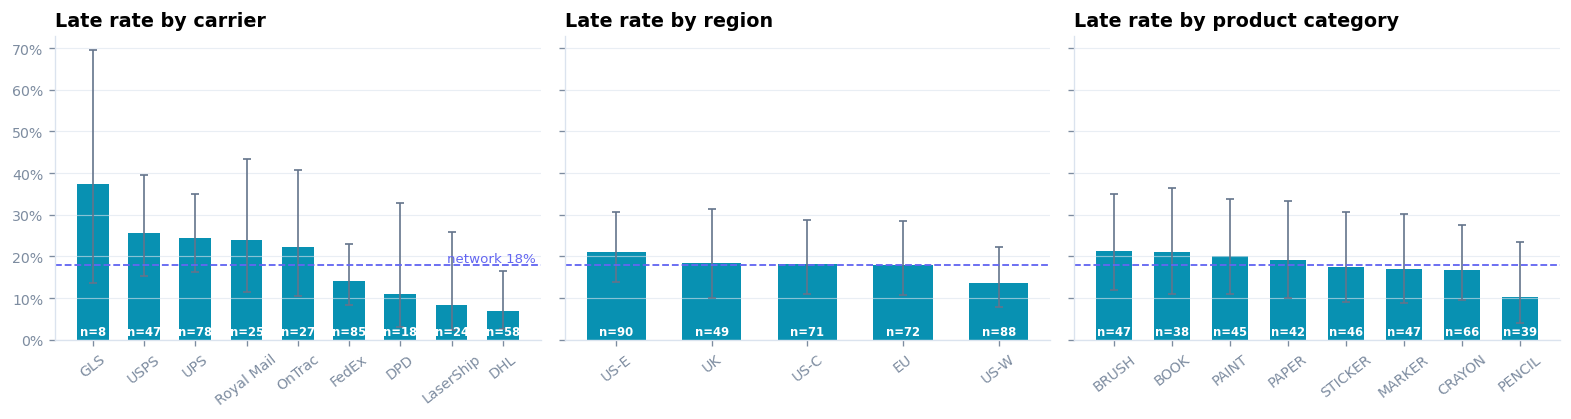

Every interval overlaps the network average. Nothing here is conclusive on its own;
the models in section 5 are the proper test of whether these differences generalize.


In [4]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.6), sharey=True)
for ax, col in zip(axes, ["carrier", "region", "product_category"]):
    g = completed.groupby(col)["late"].agg(["sum", "count"])
    g["rate"] = g["sum"] / g["count"]
    g = g.sort_values("rate", ascending=False)
    lo, hi = zip(*[wilson(k, n) for k, n in zip(g["sum"], g["count"])])
    err = np.vstack([g["rate"] - np.array(lo), np.array(hi) - g["rate"]])

    style_ax(ax)
    ax.bar(g.index, g["rate"], color=CYAN, width=0.62,
           yerr=err, ecolor=SLATE, error_kw={"elinewidth": 1, "capsize": 2.5})
    for i, (rate, n) in enumerate(zip(g["rate"], g["count"])):
        ax.annotate(f"n={n}", (i, 0.005), ha="center", va="bottom", fontsize=7, color="white",
                    fontweight="bold")
    ax.axhline(completed.late.mean(), color=INDIGO, lw=1.1, ls="--")
    ax.set_title(f"Late rate by {col.replace('_', ' ')}")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=38)

axes[0].annotate(f"network {completed.late.mean():.0%}", xy=(0.99, completed.late.mean()),
                 xycoords=("axes fraction", "data"), ha="right", va="bottom", fontsize=8, color=INDIGO)
plt.tight_layout()
plt.show()

print("Every interval overlaps the network average. Nothing here is conclusive on its own;")
print("the models in section 5 are the proper test of whether these differences generalize.")

## 5. Models, validated honestly

Three models, in increasing order of capacity: the class prior baseline (predicts the same
probability for everyone), L2 regularized logistic regression with balanced class weights (the
preregistered reference model), and a random forest. Encoders and scalers are inside the
pipeline, so every fold is leakage safe.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CAT = ["carrier", "region", "warehouse", "product_category", "order_month"]
NUM = ["quantity", "unit_price_usd", "is_promo"]

X = completed[CAT + NUM].copy()
X["order_month"] = X["order_month"].astype(str)
y = completed["late"].to_numpy()

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("num", StandardScaler(), NUM),
    ]
)

models = {
    "dummy (prior)": DummyClassifier(strategy="prior"),
    "logistic regression": Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    ),
    "random forest": Pipeline(
        [
            ("pre", pre),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=42
                ),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"])
    rows.append({
        "model": name,
        "ROC AUC (CV)": f"{scores['test_roc_auc'].mean():.3f} +/- {scores['test_roc_auc'].std():.3f}",
        "PR AUC (CV)": f"{scores['test_average_precision'].mean():.3f} +/- {scores['test_average_precision'].std():.3f}",
        "_auc": scores["test_roc_auc"].mean(),
        "_std": scores["test_roc_auc"].std(),
    })

results = pd.DataFrame(rows).set_index("model")
LR_AUC = float(results.loc["logistic regression", "_auc"])
results.drop(columns=["_auc", "_std"])

,ROC AUC (CV),PR AUC (CV)
model,,
dummy (prior),0.500 +/- 0.000,0.178 +/- 0.005
logistic regression,0.465 +/- 0.044,0.182 +/- 0.024
random forest,0.466 +/- 0.052,0.193 +/- 0.031


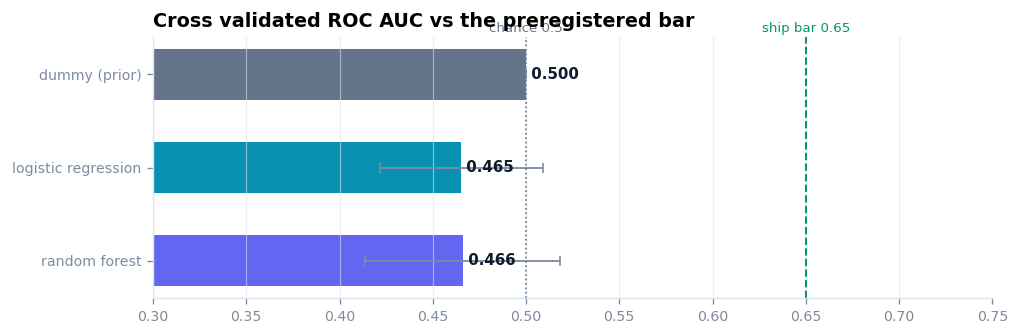

Reference model (logistic regression) CV AUC: 0.465 -> below chance, far below the 0.65 bar.
Both real models LOSE to coin flipping. Capacity is not the issue; the features carry no signal.


In [6]:
fig, ax = plt.subplots(figsize=(8.6, 2.9))
style_ax(ax, ygrid_only=False)
ax.grid(axis="y", visible=False)

names = list(results.index)[::-1]
aucs = list(results["_auc"])[::-1]
stds = list(results["_std"])[::-1]
bar_colors = [SLATE if n.startswith("dummy") else (INDIGO if "forest" in n else CYAN) for n in names]

ax.barh(names, aucs, xerr=stds, color=bar_colors, height=0.55,
        ecolor=INK3, error_kw={"elinewidth": 1.1, "capsize": 3})
for i, v in enumerate(aucs):
    ax.annotate(f" {v:.3f}", (v, i), va="center", fontsize=9, color=INK, fontweight="bold")

ax.axvline(0.5, color=SLATE, lw=1, ls=":")
ax.annotate("chance 0.5", xy=(0.5, 1.02), xycoords=("data", "axes fraction"), ha="center", fontsize=8, color=SLATE)
ax.axvline(0.65, color=GREEN, lw=1.2, ls="--")
ax.annotate("ship bar 0.65", xy=(0.65, 1.02), xycoords=("data", "axes fraction"), ha="center", fontsize=8, color=GREEN)
ax.set_xlim(0.30, 0.75)
ax.set_title("Cross validated ROC AUC vs the preregistered bar")
plt.tight_layout()
plt.show()

print(f"Reference model (logistic regression) CV AUC: {LR_AUC:.3f} -> below chance, far below the 0.65 bar.")
print("Both real models LOSE to coin flipping. Capacity is not the issue; the features carry no signal.")

## 6. The permutation test: is 0.465 distinguishable from luck?

An AUC below 0.5 invites a tempting fallacy ("just invert the predictions!"). The honest
question is whether the score is *outside the distribution of scores a no signal world
produces*. We rebuild that world 100 times by shuffling the labels and rerunning the full cross
validation.

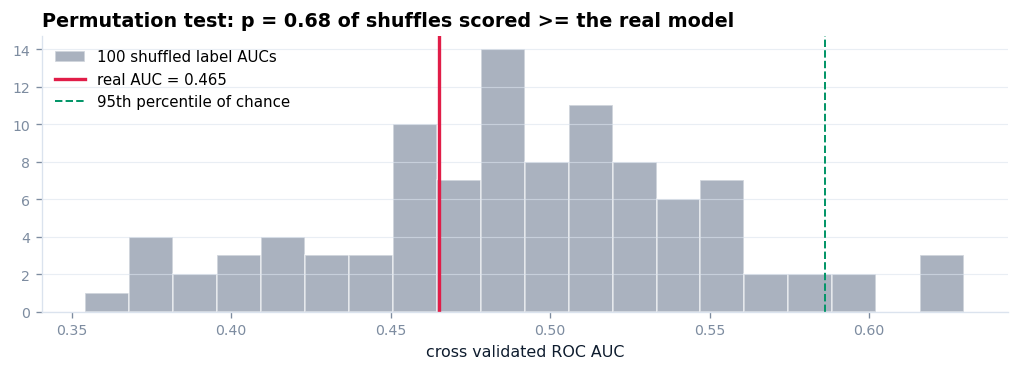

Real CV AUC:            0.465
Chance distribution:    mean 0.491, 95th percentile 0.586
Permutation p value:    0.68  (need < 0.05)

The real model sits comfortably INSIDE the chance distribution. There is nothing to invert,
and nothing to ship.


In [7]:
from sklearn.model_selection import cross_val_score

def cv_auc(labels: np.ndarray) -> float:
    lr = Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    )
    return cross_val_score(lr, X, labels, cv=cv, scoring="roc_auc").mean()

perm_aucs = np.array([cv_auc(RNG.permutation(y)) for _ in range(100)])
p_value = float((perm_aucs >= LR_AUC).mean())

fig, ax = plt.subplots(figsize=(8.6, 3.2))
style_ax(ax)
ax.hist(perm_aucs, bins=20, color=SLATE, alpha=0.55, edgecolor="white", label="100 shuffled label AUCs")
ax.axvline(LR_AUC, color=RED, lw=2, label=f"real AUC = {LR_AUC:.3f}")
ax.axvline(np.percentile(perm_aucs, 95), color=GREEN, lw=1.2, ls="--", label="95th percentile of chance")
ax.set_title(f"Permutation test: p = {p_value:.2f} of shuffles scored >= the real model")
ax.set_xlabel("cross validated ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Real CV AUC:            {LR_AUC:.3f}")
print(f"Chance distribution:    mean {perm_aucs.mean():.3f}, 95th percentile {np.percentile(perm_aucs, 95):.3f}")
print(f"Permutation p value:    {p_value:.2f}  (need < 0.05)")
print()
print("The real model sits comfortably INSIDE the chance distribution. There is nothing to invert,")
print("and nothing to ship.")

## 7. Why is there no signal? Coefficient instability

If carrier or region genuinely drove lateness, their logistic regression coefficients would
keep the same sign and roughly the same size in every training fold. Instead, the largest
coefficients swing wildly, and several flip sign fold to fold: the model is memorizing fold
specific noise, exactly what the permutation test detected.

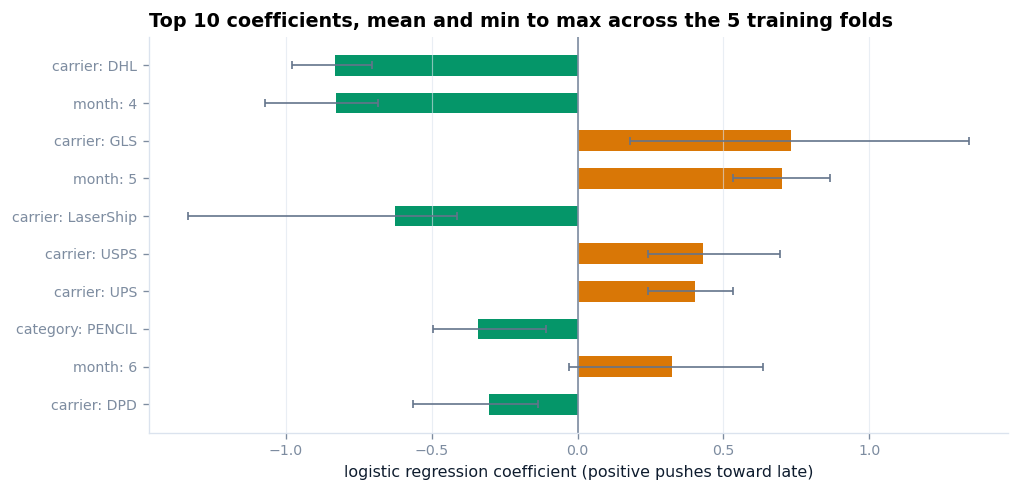

24 of 46 encoded features flip sign across folds.
Ranges that straddle zero mean even the direction of the effect is not stable.


In [8]:
coef_rows = []
for tr_idx, _ in cv.split(X, y):
    lr = Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    ).fit(X.iloc[tr_idx], y[tr_idx])
    names = list(lr.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(CAT)) + NUM
    coef_rows.append(pd.Series(lr.named_steps["clf"].coef_[0], index=names))

coefs = pd.DataFrame(coef_rows)
summary = pd.DataFrame({"mean": coefs.mean(), "lo": coefs.min(), "hi": coefs.max()})
top = summary.reindex(summary["mean"].abs().sort_values(ascending=False).index).head(10).iloc[::-1]
labels = [n.replace("carrier_", "carrier: ").replace("region_", "region: ")
            .replace("warehouse_", "warehouse: ").replace("product_category_", "category: ")
            .replace("order_month_", "month: ") for n in top.index]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
style_ax(ax, ygrid_only=False)
ax.grid(axis="y", visible=False)
ax.axvline(0, color=INK3, lw=1)
err = np.vstack([top["mean"] - top["lo"], top["hi"] - top["mean"]])
colors = [GREEN if m < 0 else AMBER for m in top["mean"]]
ax.barh(labels, top["mean"], xerr=err, color=colors, height=0.55,
        ecolor=SLATE, error_kw={"elinewidth": 1, "capsize": 2.5})
ax.set_title("Top 10 coefficients, mean and min to max across the 5 training folds")
ax.set_xlabel("logistic regression coefficient (positive pushes toward late)")
plt.tight_layout()
plt.show()

flippers = int(((coefs.min() < 0) & (coefs.max() > 0)).sum())
print(f"{flippers} of {coefs.shape[1]} encoded features flip sign across folds.")
print("Ranges that straddle zero mean even the direction of the effect is not stable.")

## 8. The preregistered decision

Both criteria are evaluated mechanically against the bar fixed in section 1. No judgment calls,
no peeking adjustments.

In [9]:
import json

SHIP = (LR_AUC >= 0.65) and (p_value < 0.05)
outdir = Path("model")
outdir.mkdir(exist_ok=True)

print(f"criterion 1   AUC >= 0.65     {'PASS' if LR_AUC >= 0.65 else 'FAIL'}   (measured {LR_AUC:.3f})")
print(f"criterion 2   perm p < 0.05   {'PASS' if p_value < 0.05 else 'FAIL'}   (measured {p_value:.2f})")
print()
print(f"DECISION: {'SHIP, exporting the model for the agent tool' if SHIP else 'DO NOT SHIP a per order risk tool'}")

if SHIP:
    lr = Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    ).fit(X, y)
    enc = lr.named_steps["pre"].named_transformers_["cat"]
    scaler = lr.named_steps["pre"].named_transformers_["num"]
    clf = lr.named_steps["clf"]
    feature_names = list(enc.get_feature_names_out(CAT)) + NUM
    payload = {
        "kind": "logistic_regression",
        "target": "late (delayed|exception) vs delivered, completed orders only",
        "metrics": {"cv_roc_auc": round(LR_AUC, 4), "permutation_p": round(p_value, 4)},
        "categorical": {c: sorted(completed[c].astype(str).unique().tolist()) for c in CAT},
        "numeric": {
            n: {"mean": float(m), "scale": float(s)}
            for n, m, s in zip(NUM, scaler.mean_, scaler.scale_)
        },
        "features": feature_names,
        "coefficients": [round(float(c), 6) for c in clf.coef_[0]],
        "intercept": round(float(clf.intercept_[0]), 6),
    }
    (outdir / "delay_risk_model.json").write_text(json.dumps(payload, indent=2))
    print("Exported -> model/delay_risk_model.json")
else:
    decision = f"""# Decision: no ML prediction tool shipped

The preregistered bar was: 5 fold CV ROC AUC >= 0.65 AND permutation p < 0.05.

Measured: AUC = {LR_AUC:.3f}, permutation p = {p_value:.2f} (n = {len(completed)} completed
orders, {int(y.sum())} late). At this sample size the apparent structure (for example carrier
delay differences) is not separable from chance with enough confidence to put a probability in
front of an operations user. A confident but wrong risk score is worse than none.

What would change this: roughly 10x more orders, or a target with stronger drivers such as
route level transit times.
"""
    (outdir / "DECISION.md").write_text(decision)
    print("Wrote -> model/DECISION.md")

criterion 1   AUC >= 0.65     FAIL   (measured 0.465)
criterion 2   perm p < 0.05   FAIL   (measured 0.68)

DECISION: DO NOT SHIP a per order risk tool
Wrote -> model/DECISION.md


## 9. Limitations, and what would change the verdict

* **The dataset is mock and small.** 370 completed orders with 66 late events. This study is an
  exercise in honest methodology, not production forecasting.
* **Absence of evidence here is not evidence of absence everywhere.** With ~10x the orders the
  same protocol would have the power to detect a real 5 to 10 point carrier effect, and richer
  features (route level transit times, weather, warehouse load) could carry signal these order
  fields do not.
* **Per SKU modeling stays off the table** regardless: 355 SKUs across 400 orders is ~1 order of
  history per SKU. The product's forecasting falls back to the category level automatically.
* **What the product does instead.** Demand forecasting uses simple, explainable methods (moving
  average, linear trend, exponential smoothing) selected by a 3 month backtest, and the ML Lab
  exposes this whole study interactively, so the no ship decision stays inspectable rather than
  buried in a notebook.